# CMP7239 - Applied Machine Learning: DDoS Attack Detection

- **ML Models:** Logistic Regression, Support Vector Machine (SVM), Gaussian Naive Bayes, AdaBoost
- **DL Models:** Long Short-Term Memory (LSTM), Deep Autoencoder Classifier

---
## 1. Environment Setup and Library Imports

In [1]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
import os
import gc
from collections import Counter

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="darkgrid", palette="deep")

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.calibration import CalibratedClassifierCV

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, LSTM, Reshape, Input,
                                      BatchNormalization, Activation)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print("=" * 50)
print("Environment Ready")
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("=" * 50)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Environment Ready
TensorFlow: 2.20.0
NumPy: 2.3.5
Pandas: 3.0.0


---
## 2. Data Ingestion

The CIC-DDoS2019 dataset was generated by the Canadian Institute for
Cybersecurity using CICFlowMeter-V3 and contains 88 network flow features
across multiple CSV files covering various DDoS attack types.

In [2]:
# Discover all CSV files
input_dir = '/kaggle/input'
csv_files = []
for root, dirs, files in os.walk(input_dir):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))
            
print(f"Discovered {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  → {f}")

Discovered 18 CSV files:
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/NetBIOS.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDPLag.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Syn.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/MSSQL.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Portmap.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDP.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/LDAP.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_NetBIOS.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_SSDP.csv
  → /kaggle/input/datasets/rodrigorosasilva/cic-ddos2

In [3]:
# Load data with stratified sampling per file
MAX_ROWS_PER_FILE = 60000
frames = []

for filepath in csv_files:
    try:
        chunk = pd.read_csv(filepath, low_memory=False)
        if len(chunk) > MAX_ROWS_PER_FILE:
            chunk = chunk.sample(n=MAX_ROWS_PER_FILE, random_state=123)
        frames.append(chunk)
        print(f"  Loaded: {os.path.basename(filepath)} → {chunk.shape}")
    except Exception as e:
        print(f"  Skipped: {os.path.basename(filepath)} → {e}")

data = pd.concat(frames, ignore_index=True)
print(f"\n{'='*50}")
print(f"COMBINED DATASET: {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"{'='*50}")

del frames
gc.collect()

  Loaded: NetBIOS.csv → (60000, 88)
  Loaded: UDPLag.csv → (60000, 88)
  Loaded: Syn.csv → (60000, 88)
  Loaded: MSSQL.csv → (60000, 88)
  Loaded: Portmap.csv → (60000, 88)
  Loaded: UDP.csv → (60000, 88)
  Loaded: LDAP.csv → (60000, 88)
  Loaded: DrDoS_NetBIOS.csv → (60000, 88)
  Loaded: DrDoS_SSDP.csv → (60000, 88)
  Loaded: DrDoS_NTP.csv → (60000, 88)
  Loaded: TFTP.csv → (60000, 88)
  Loaded: UDPLag.csv → (60000, 88)
  Loaded: DrDoS_UDP.csv → (60000, 88)
  Loaded: Syn.csv → (60000, 88)
  Loaded: DrDoS_MSSQL.csv → (60000, 88)
  Loaded: DrDoS_SNMP.csv → (60000, 88)
  Loaded: DrDoS_DNS.csv → (60000, 88)
  Loaded: DrDoS_LDAP.csv → (60000, 88)

COMBINED DATASET: 1,080,000 rows × 88 columns


0

In [4]:
# Clean column names
data.columns = data.columns.str.strip()

# Show sample
print("Sample rows:")
data.head(3)

Sample rows:


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,63396,172.16.0.5-192.168.50.4-635-34026-17,172.16.0.5,635,192.168.50.4,34026,17,2018-11-03 10:05:36.257741,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
1,238375,172.16.0.5-192.168.50.4-758-12176-17,172.16.0.5,758,192.168.50.4,12176,17,2018-11-03 10:05:03.216046,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
2,66106,172.16.0.5-192.168.50.4-648-58320-17,172.16.0.5,648,192.168.50.4,58320,17,2018-11-03 10:05:19.548460,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS


---
## 3. Exploratory Data Analysis (EDA)

In [5]:
# Identify target column
target_col = None
for col in data.columns:
    if 'label' in col.lower():
        target_col = col
        break
if target_col is None:
    target_col = data.columns[-1]

print(f"Target column: '{target_col}'")
print(f"Unique labels: {data[target_col].nunique()}")
print(f"\nLabel value counts:")
label_counts = data[target_col].value_counts()
print(label_counts)

Target column: 'Label'
Unique labels: 19

Label value counts:
Label
Syn              169692
UDP               68793
NetBIOS           65676
MSSQL             60318
DrDoS_SSDP        59988
DrDoS_NetBIOS     59986
DrDoS_MSSQL       59983
DrDoS_SNMP        59976
DrDoS_DNS         59970
DrDoS_LDAP        59965
DrDoS_UDP         59947
TFTP              59933
UDP-lag           59351
DrDoS_NTP         59279
Portmap           58482
LDAP              54243
BENIGN             4209
UDPLag              146
WebDDoS              63
Name: count, dtype: int64


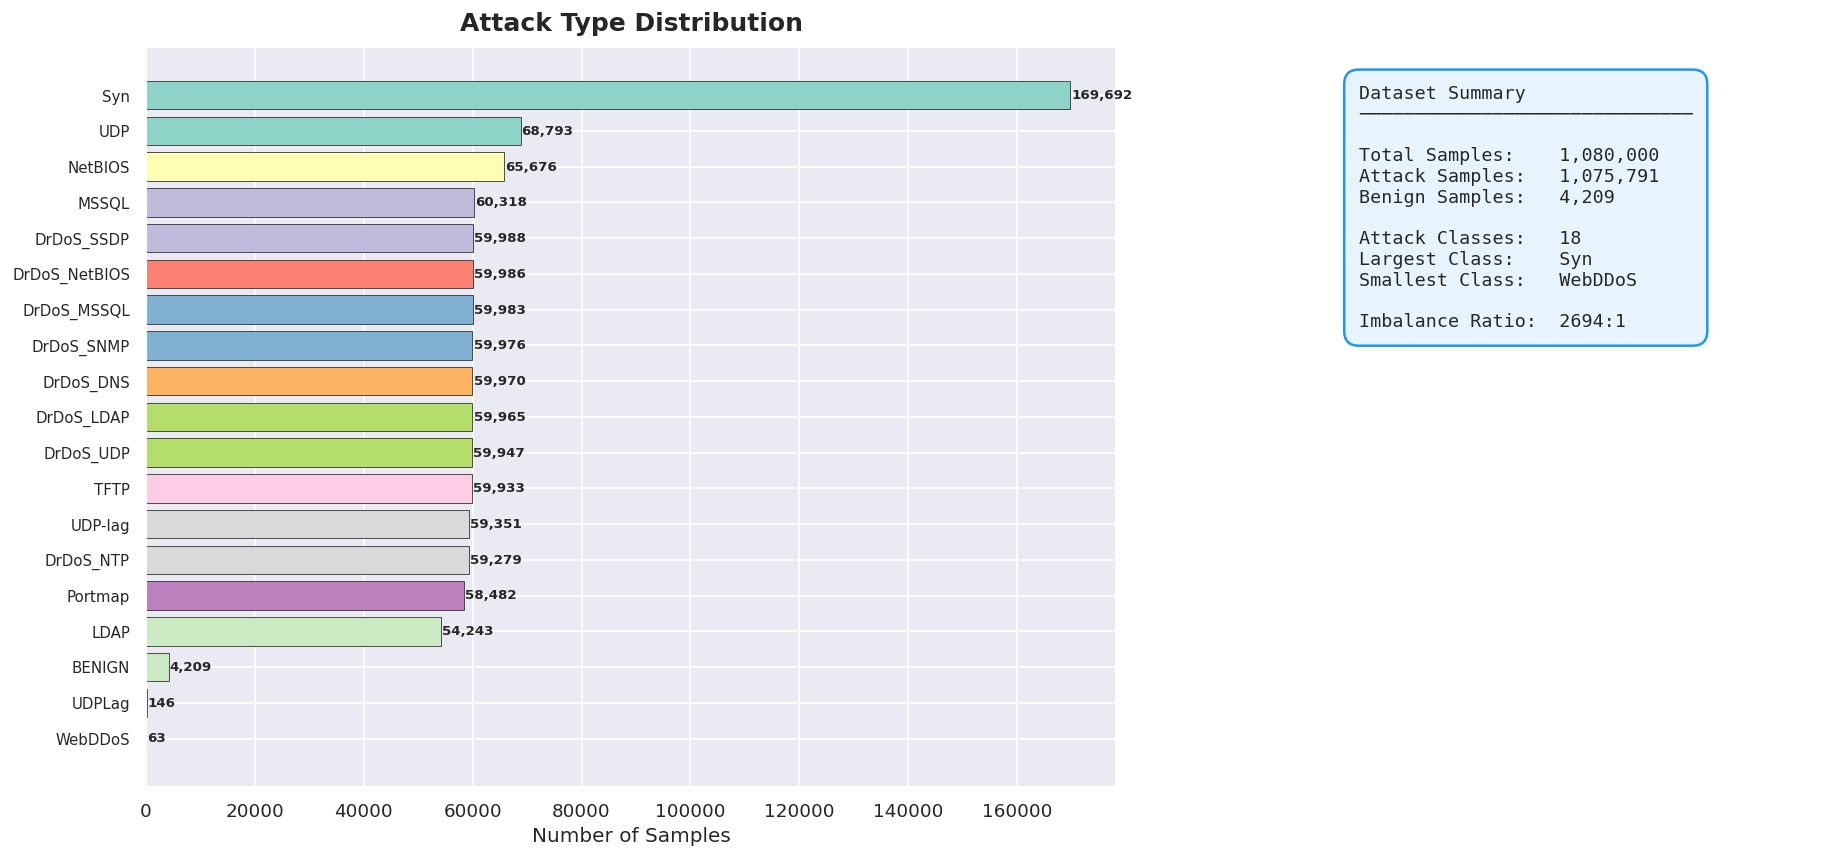

In [6]:
# Figure 1: Attack Type Distribution (Horizontal Bar + Summary Stats)
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.3)

ax1 = fig.add_subplot(gs[0])
colors = plt.cm.Set3(np.linspace(0, 1, len(label_counts)))
bars = ax1.barh(range(len(label_counts)), label_counts.values, color=colors, edgecolor='#333', linewidth=0.5)
ax1.set_yticks(range(len(label_counts)))
ax1.set_yticklabels(label_counts.index, fontsize=9)
ax1.set_xlabel('Number of Samples', fontsize=12)
ax1.set_title('Attack Type Distribution', fontsize=15, fontweight='bold', pad=10)
ax1.invert_yaxis()

for bar, val in zip(bars, label_counts.values):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', ha='left', va='center', fontsize=8, fontweight='bold')

# Summary panel
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')
total = label_counts.sum()
attack_total = total - label_counts.get('BENIGN', 0)
benign_total = label_counts.get('BENIGN', 0)

summary = (
    f"Dataset Summary\n"
    f"{'─'*30}\n\n"
    f"Total Samples:    {total:,}\n"
    f"Attack Samples:   {attack_total:,}\n"
    f"Benign Samples:   {benign_total:,}\n\n"
    f"Attack Classes:   {len(label_counts) - 1}\n"
    f"Largest Class:    {label_counts.index[0]}\n"
    f"Smallest Class:   {label_counts.index[-1]}\n\n"
    f"Imbalance Ratio:  {label_counts.values[0]/label_counts.values[-1]:.0f}:1"
)
ax2.text(0.05, 0.95, summary, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F4FD', edgecolor='#2196F3', linewidth=1.5))

plt.savefig('fig1_attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Data types and missing values overview
print("DATA TYPES:")
print(data.dtypes.value_counts())

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Non-numeric features: {len(non_numeric_cols)} → {non_numeric_cols}")

DATA TYPES:
float64    45
int64      37
str         6
Name: count, dtype: int64

Numeric features: 82
Non-numeric features: 6 → ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP', 'Label']


In [8]:
# Missing value analysis
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_info = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_info = missing_info[missing_info['Count'] > 0].sort_values('Percent', ascending=False)

print(f"Features with missing values: {len(missing_info)}")
if len(missing_info) > 0:
    print(missing_info)

Features with missing values: 1
              Count   Percent
Flow Bytes/s  13332  1.234444


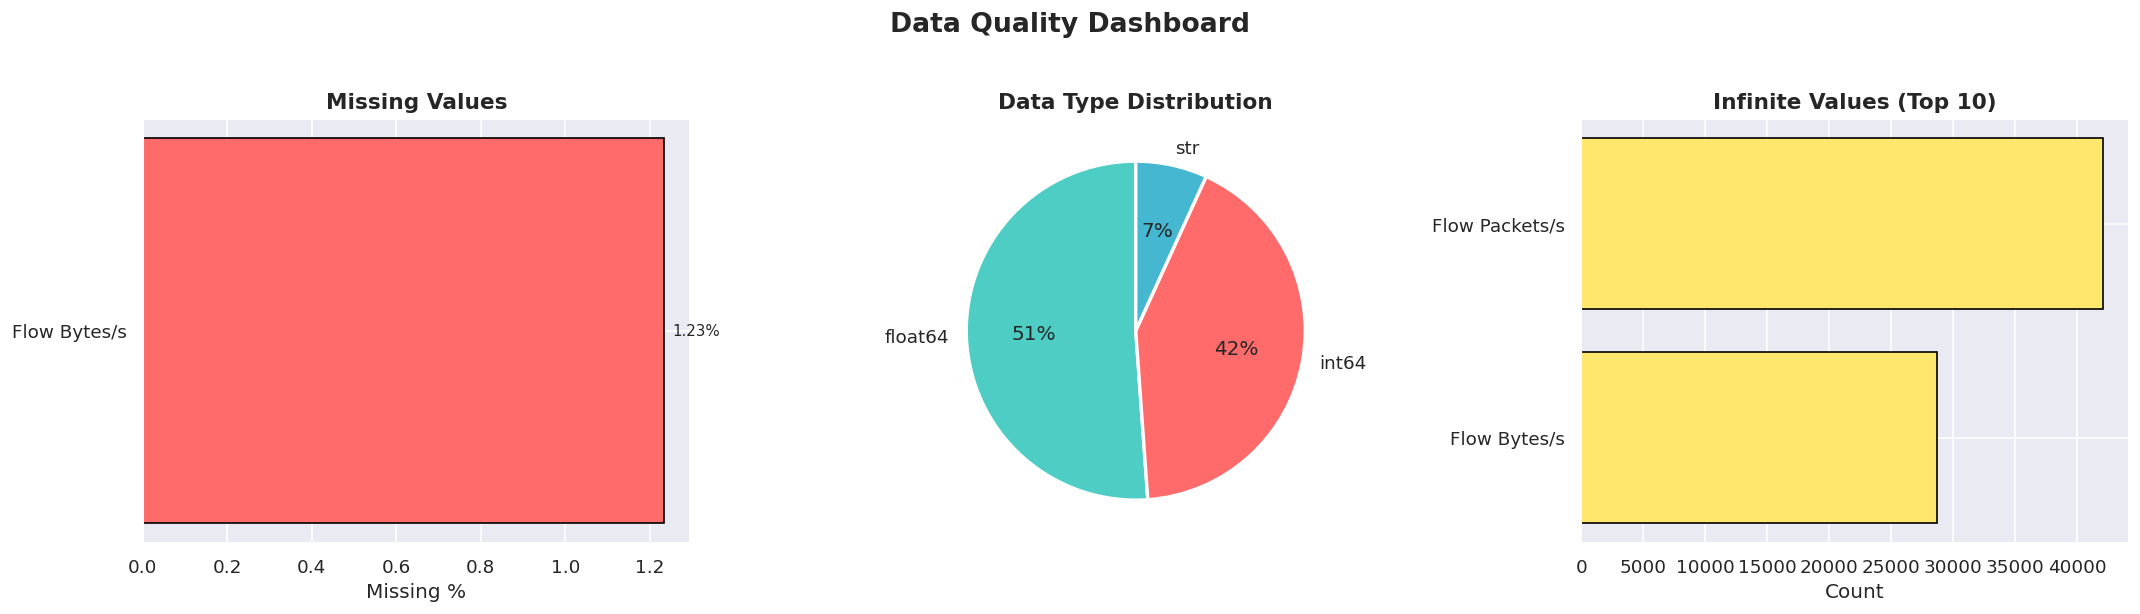

In [9]:
# Figure 2: Data Quality Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Missing values
if len(missing_info) > 0:
    axes[0].barh(missing_info.index[:15], missing_info['Percent'][:15], color='#FF6B6B', edgecolor='black')
    axes[0].set_xlabel('Missing %')
    axes[0].set_title('Missing Values', fontsize=13, fontweight='bold')
    for i, (idx, row) in enumerate(missing_info[:15].iterrows()):
        axes[0].text(row['Percent'] + 0.02, i, f"{row['Percent']:.2f}%", va='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', fontsize=14, fontweight='bold', color='green',
                 transform=axes[0].transAxes)
    axes[0].set_title('Missing Values', fontsize=13, fontweight='bold')

# Data type breakdown
dtype_counts = data.dtypes.value_counts()
axes[1].pie(dtype_counts.values, labels=[str(d) for d in dtype_counts.index], autopct='%1.0f%%',
            colors=['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Data Type Distribution', fontsize=13, fontweight='bold')

# Infinite values per column
inf_counts = {}
for col in numeric_cols:
    inf_count = np.isinf(data[col].astype(float, errors='ignore')).sum() if data[col].dtype != object else 0
    if inf_count > 0:
        inf_counts[col] = inf_count

if inf_counts:
    inf_df = pd.Series(inf_counts).sort_values(ascending=True).tail(10)
    axes[2].barh(inf_df.index, inf_df.values, color='#FFE66D', edgecolor='black')
    axes[2].set_xlabel('Count')
    axes[2].set_title('Infinite Values (Top 10)', fontsize=13, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'No Infinite Values!', ha='center', va='center', fontsize=14, fontweight='bold', color='green',
                 transform=axes[2].transAxes)
    axes[2].set_title('Infinite Values', fontsize=13, fontweight='bold')

plt.suptitle('Data Quality Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Data Preprocessing

In [10]:
# Step 1: Drop identifier columns
drop_cols = []
for col in data.columns:
    cl = col.lower()
    if any(kw in cl for kw in ['timestamp', 'flow id', 'source ip', 'destination ip',
                                'src ip', 'dst ip', 'source port', 'destination port',
                                'unnamed', 'flow_id']):
        drop_cols.append(col)

drop_cols = [c for c in drop_cols if c != target_col]
data.drop(columns=drop_cols, inplace=True, errors='ignore')
print(f"Dropped identifiers: {drop_cols}")
print(f"Shape: {data.shape}")

Dropped identifiers: ['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
Shape: (1080000, 81)


In [11]:
# Step 2: Handle infinite and extreme values
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

print("Replacing infinite values...")
for col in numeric_cols:
    inf_mask = np.isinf(data[col])
    if inf_mask.sum() > 0:
        data[col].replace([np.inf, -np.inf], np.nan, inplace=True)
        print(f"  {col}: {inf_mask.sum()} inf values replaced")

# Cap outliers at 0.1st and 99.9th percentile
print("\nCapping outliers...")
for col in numeric_cols:
    q_low = data[col].quantile(0.001)
    q_high = data[col].quantile(0.999)
    data[col] = data[col].clip(lower=q_low, upper=q_high)

# Fill remaining NaN with median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
print(f"Remaining NaN: {data.isnull().sum().sum()}")

Replacing infinite values...
  Flow Bytes/s: 28719 inf values replaced
  Flow Packets/s: 42051 inf values replaced

Capping outliers...
Remaining NaN: 0


In [12]:
# Step 3: Remove duplicates
before = len(data)
data.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(data):,}")
print(f"Shape after dedup: {data.shape}")

Duplicates removed: 802,972
Shape after dedup: (277028, 81)


In [13]:
# Step 4: Encode target - Multi-class
le = LabelEncoder()
data['target'] = le.fit_transform(data[target_col])

print("Label Encoding:")
for i, cls in enumerate(le.classes_):
    n = (data['target'] == i).sum()
    print(f"  {i:2d} → {cls:20s} ({n:>7,} samples)")

n_classes = len(le.classes_)

Label Encoding:
   0 → BENIGN               (  3,937 samples)
   1 → DrDoS_DNS            (  6,188 samples)
   2 → DrDoS_LDAP           (  3,584 samples)
   3 → DrDoS_MSSQL          ( 14,577 samples)
   4 → DrDoS_NTP            ( 55,998 samples)
   5 → DrDoS_NetBIOS        (  1,472 samples)
   6 → DrDoS_SNMP           (  6,887 samples)
   7 → DrDoS_SSDP           ( 29,976 samples)
   8 → DrDoS_UDP            ( 30,344 samples)
   9 → LDAP                 (  2,396 samples)
  10 → MSSQL                ( 15,963 samples)
  11 → NetBIOS              (    961 samples)
  12 → Portmap              (    866 samples)
  13 → Syn                  ( 23,415 samples)
  14 → TFTP                 ( 29,529 samples)
  15 → UDP                  ( 35,171 samples)
  16 → UDP-lag              ( 15,606 samples)
  17 → UDPLag               (     96 samples)
  18 → WebDDoS              (     62 samples)


In [14]:
# Step 5: Separate features and target
X = data.drop(columns=[target_col, 'target']).select_dtypes(include=[np.number])
y = data['target']

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]:,}")
assert X.shape[1] >= 50, f"Need >= 50 features, got {X.shape[1]}"
assert X.shape[0] >= 5000, f"Need >= 5000 rows, got {X.shape[0]}"
print(f"✓ Requirements met: {X.shape[1]} features, {X.shape[0]:,} rows")

Features: 79
Samples:  277,028
✓ Requirements met: 79 features, 277,028 rows


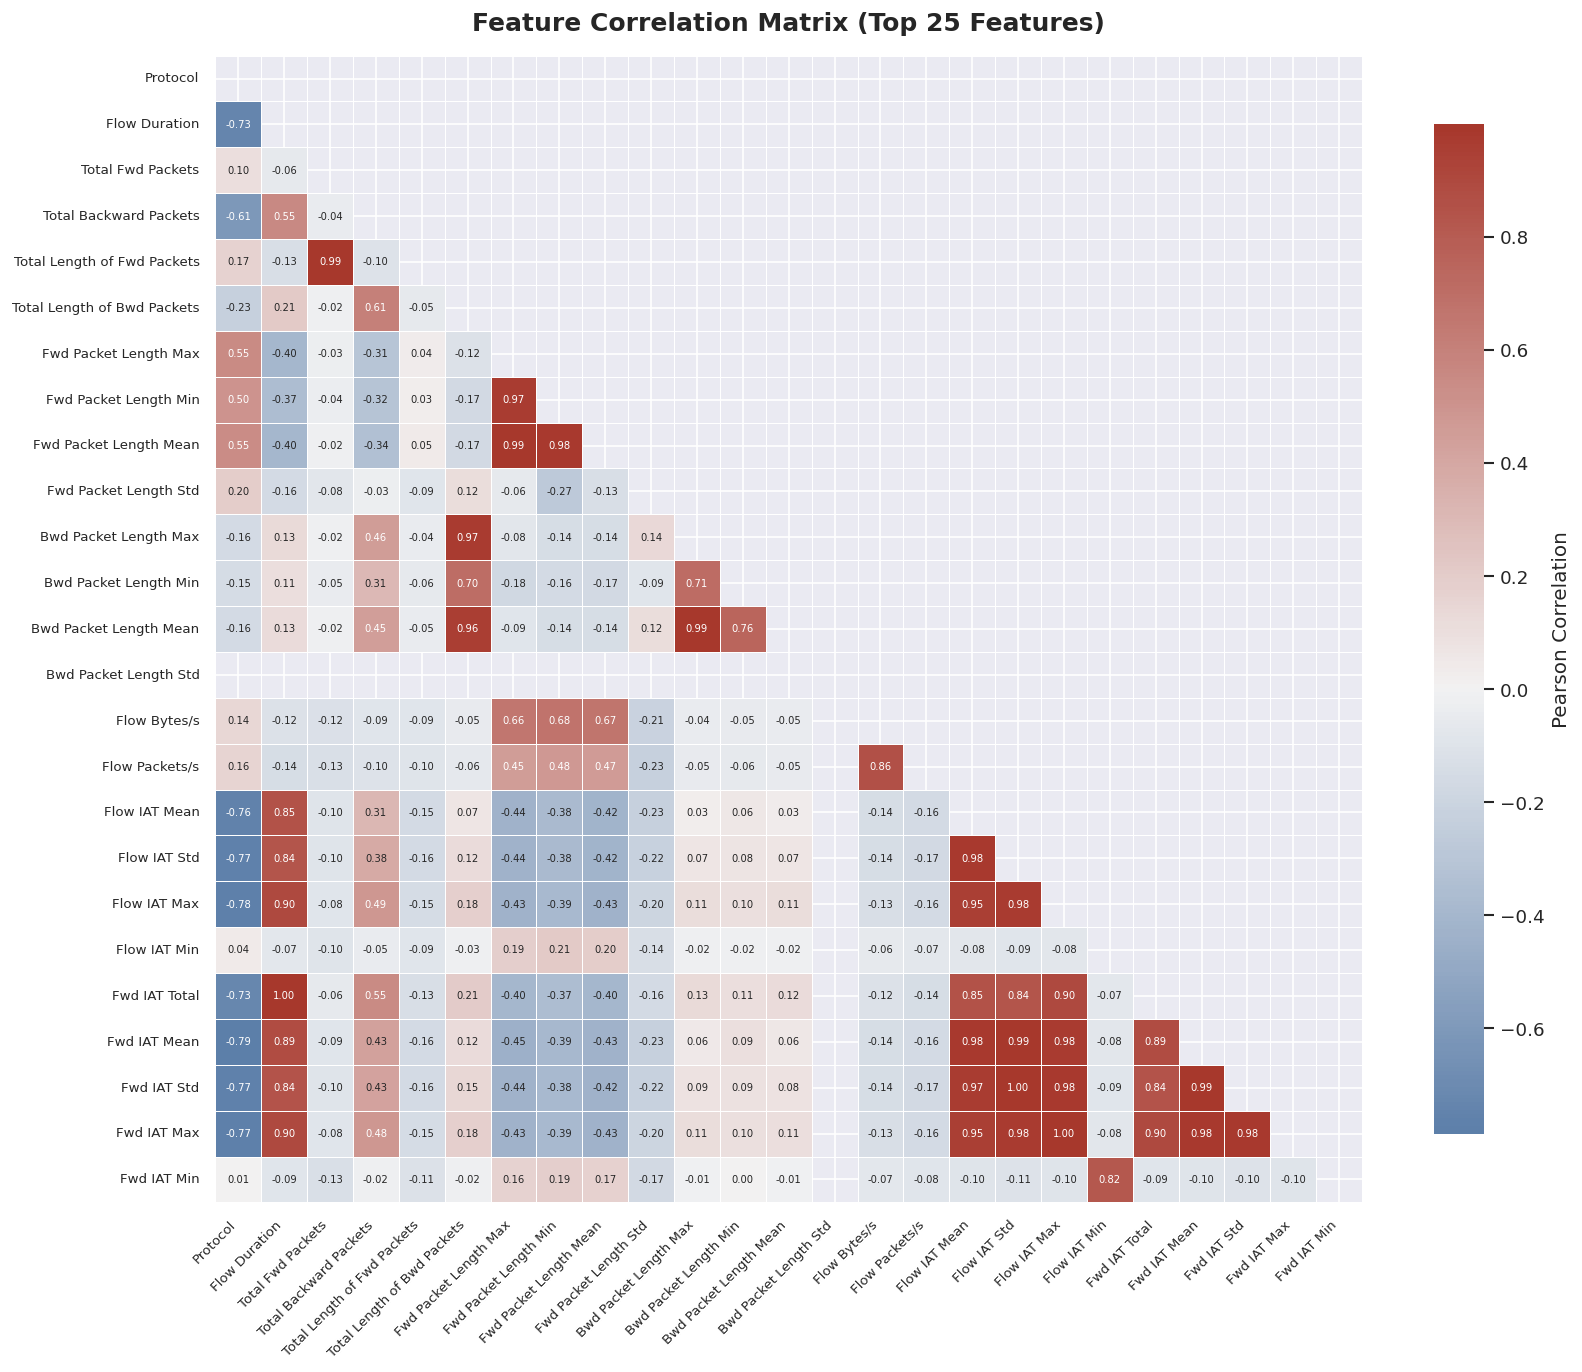

In [15]:
# Figure 3: Feature Correlation Matrix (Top 25)
fig, ax = plt.subplots(figsize=(14, 12))
top25 = X.iloc[:, :25]
corr = top25.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.3, ax=ax, annot_kws={"size": 6},
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
ax.set_title('Feature Correlation Matrix (Top 25 Features)', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Step 6: Feature Scaling using MinMaxScaler (different from StandardScaler)

# Clean remaining inf and extreme values
print("Cleaning remaining infinite and extreme values...")
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Cap extreme values at 99.9th percentile per column
for col in X.columns:
    upper = X[col].quantile(0.999)
    lower = X[col].quantile(0.001)
    X[col] = X[col].clip(lower=lower, upper=upper)

# Fill any NaN created from inf replacement
X.fillna(X.median(), inplace=True)

# Verify clean
print(f"Infinite values remaining: {np.isinf(X.values).sum()}")
print(f"NaN values remaining:      {np.isnan(X.values).sum()}")

# Now scale
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
print(f"MinMaxScaler applied → Range: [{X_scaled.min().min():.4f}, {X_scaled.max().max():.4f}]")

Cleaning remaining infinite and extreme values...
Infinite values remaining: 0
NaN values remaining:      0
MinMaxScaler applied → Range: [0.0000, 1.0000]


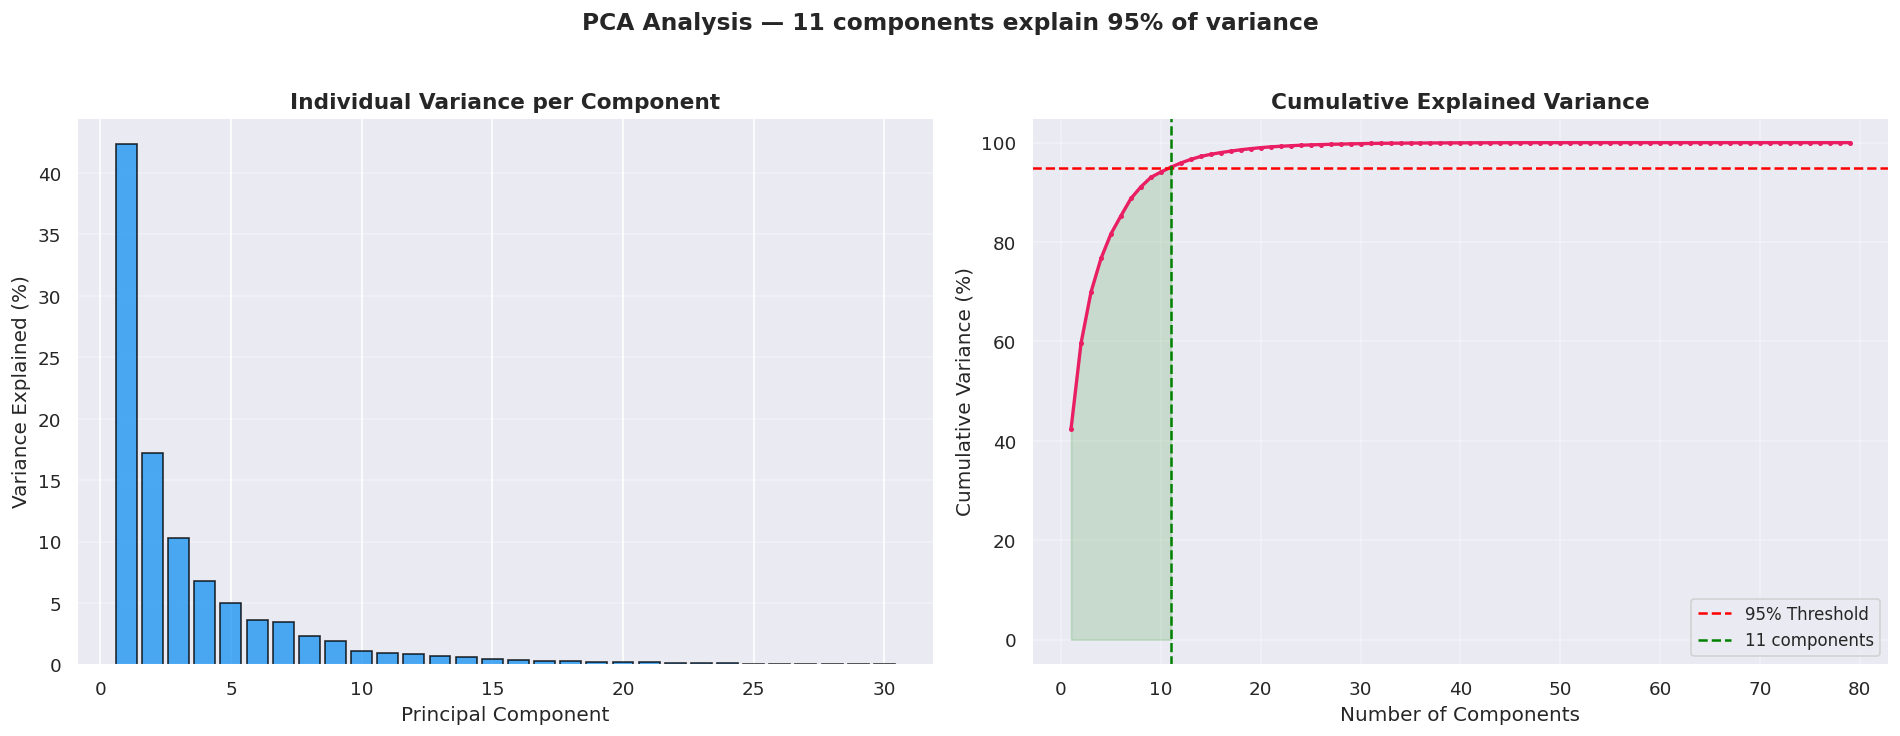


Components for 95% variance: 11


In [18]:
# Step 7: PCA for dimensionality reduction analysis
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Figure 4: PCA Variance Explained
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30] * 100,
            color='#2196F3', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('Individual Variance per Component', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100,
             'b-o', markersize=2, linewidth=2, color='#E91E63')
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% Threshold')
axes[1].axvline(x=n_components_95, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_components_95} components')
axes[1].fill_between(range(1, n_components_95+1),
                     cumulative_variance[:n_components_95]*100, alpha=0.15, color='green')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle(f'PCA Analysis — {n_components_95} components explain 95% of variance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComponents for 95% variance: {n_components_95}")

In [19]:
# Apply PCA (keep 95% variance)
pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components_95)])

print(f"PCA reduced: {X_scaled.shape[1]} features → {X_pca.shape[1]} components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA reduced: 79 features → 11 components
Variance retained: 95.06%


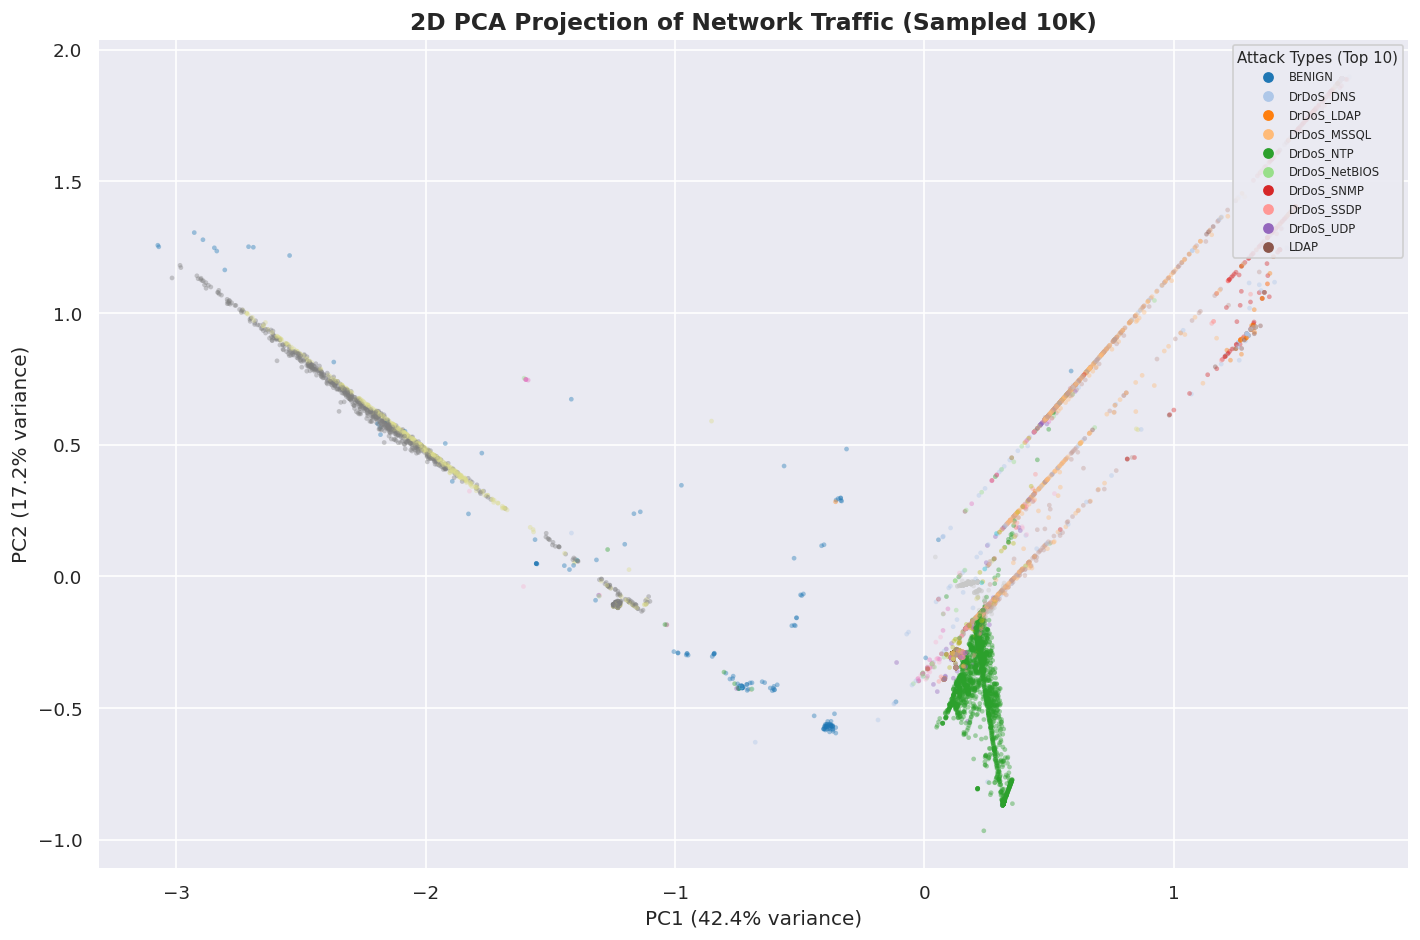

In [20]:
# Figure 5: 2D PCA Scatter Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Sample for visualization
sample_idx = np.random.choice(len(X_pca), min(10000, len(X_pca)), replace=False)
scatter = ax.scatter(X_pca.iloc[sample_idx, 0], X_pca.iloc[sample_idx, 1],
                     c=y.iloc[sample_idx], cmap='tab20', alpha=0.4, s=8, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('2D PCA Projection of Network Traffic (Sampled 10K)', fontsize=14, fontweight='bold')

# Create custom legend
unique_labels = sorted(y.iloc[sample_idx].unique())
handles = [plt.scatter([], [], c=[plt.cm.tab20(l / max(unique_labels))], s=30, label=le.classes_[l])
           for l in unique_labels[:10]]
ax.legend(handles=handles, title='Attack Types (Top 10)', loc='upper right',
          fontsize=7, title_fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig5_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Step 8: Train-Test Split (75:25 — different ratio from 80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, random_state=123, stratify=y
)

print(f"Training: {X_train.shape[0]:,} samples")
print(f"Testing:  {X_test.shape[0]:,} samples")
print(f"Split ratio: 75:25")

Training: 207,771 samples
Testing:  69,257 samples
Split ratio: 75:25


---
## 5. Model Training and Evaluation

Six models implemented:
1. Logistic Regression (ML)
2. Support Vector Machine — LinearSVC (ML)
3. Gaussian Naive Bayes (ML)
4. AdaBoost (ML)
5. LSTM Network (DL)
6. Deep Autoencoder Classifier (DL)

In [22]:
# Storage
results = {}
train_times = {}
preds = {}

### 5.1 Logistic Regression

In [24]:
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

lr_params = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

lr = LogisticRegression(random_state=123, n_jobs=-1)

print("Hyperparameter tuning (GridSearchCV, 3-fold)...")
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)

t0 = time.time()
lr_grid.fit(X_train, y_train)
lr_time = time.time() - t0

print(f"\nBest params: {lr_grid.best_params_}")
print(f"Best CV F1: {lr_grid.best_score_:.4f}")
print(f"Training time: {lr_time:.1f}s")

y_pred_lr = lr_grid.predict(X_test)
preds['Logistic Regression'] = y_pred_lr
train_times['Logistic Regression'] = lr_time

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_lr, average='weighted', zero_division=0),
}

print(f"\nResults:")
for m, v in results['Logistic Regression'].items():
    print(f"  {m}: {v:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))

MODEL 1: LOGISTIC REGRESSION
Hyperparameter tuning (GridSearchCV, 3-fold)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best params: {'C': 10.0, 'max_iter': 500, 'solver': 'saga'}
Best CV F1: 0.5648
Training time: 103.8s

Results:
  Accuracy: 0.6098
  Precision: 0.6008
  Recall: 0.6098
  F1-Score: 0.5644

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.90      0.95      0.92       984
    DrDoS_DNS       0.40      0.10      0.16      1547
   DrDoS_LDAP       0.38      0.25      0.30       896
  DrDoS_MSSQL       0.42      0.48      0.45      3644
    DrDoS_NTP       0.91      0.90      0.91     14000
DrDoS_NetBIOS       0.21      0.07      0.10       368
   DrDoS_SNMP       0.42      0.86      0.57      1722
   DrDoS_SSDP       0.19      0.06      0.09      7494
    DrDoS_UDP       0.39      0.02      0.03      7586
         LDAP       0.00      0.00      0.00       599
        MSSQL       0.42      0.53      0.47 

### 5.2 Support Vector Machine (LinearSVC)

In [25]:
print("=" * 60)
print("MODEL 2: SUPPORT VECTOR MACHINE (LinearSVC)")
print("=" * 60)

svm_params = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [2000]
}

svc = LinearSVC(random_state=123, dual=True)

print("Hyperparameter tuning...")
svm_grid = GridSearchCV(svc, svm_params, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)

t0 = time.time()
svm_grid.fit(X_train, y_train)
svm_time = time.time() - t0

print(f"\nBest params: {svm_grid.best_params_}")
print(f"Best CV F1: {svm_grid.best_score_:.4f}")
print(f"Training time: {svm_time:.1f}s")

y_pred_svm = svm_grid.predict(X_test)
preds['SVM (LinearSVC)'] = y_pred_svm
train_times['SVM (LinearSVC)'] = svm_time

results['SVM (LinearSVC)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_svm, average='weighted', zero_division=0),
}

print(f"\nResults:")
for m, v in results['SVM (LinearSVC)'].items():
    print(f"  {m}: {v:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_, zero_division=0))

MODEL 2: SUPPORT VECTOR MACHINE (LinearSVC)
Hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best params: {'C': 10.0, 'loss': 'squared_hinge', 'max_iter': 2000}
Best CV F1: 0.5299
Training time: 502.8s

Results:
  Accuracy: 0.5889
  Precision: 0.5747
  Recall: 0.5889
  F1-Score: 0.5304

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.88      0.95      0.91       984
    DrDoS_DNS       0.48      0.08      0.13      1547
   DrDoS_LDAP       0.33      0.23      0.27       896
  DrDoS_MSSQL       0.40      0.47      0.43      3644
    DrDoS_NTP       0.89      0.88      0.88     14000
DrDoS_NetBIOS       0.00      0.00      0.00       368
   DrDoS_SNMP       0.42      0.86      0.56      1722
   DrDoS_SSDP       0.37      0.04      0.07      7494
    DrDoS_UDP       0.35      0.02      0.04      7586
         LDAP       0.00      0.00      0.00       599
        MSSQL       0.37      0.46      0.41  

### 5.3 Gaussian Naive Bayes

In [27]:
print("=" * 60)
print("MODEL 3: GAUSSIAN NAIVE BAYES")
print("=" * 60)

gnb_params = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

gnb = GaussianNB()

print("Hyperparameter tuning...")
gnb_grid = GridSearchCV(gnb, gnb_params, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)

t0 = time.time()
gnb_grid.fit(X_train, y_train)
gnb_time = time.time() - t0

print(f"\nBest params: {gnb_grid.best_params_}")
print(f"Best CV F1: {gnb_grid.best_score_:.4f}")
print(f"Training time: {gnb_time:.1f}s")

y_pred_gnb = gnb_grid.predict(X_test)
preds['Naive Bayes'] = y_pred_gnb
train_times['Naive Bayes'] = gnb_time

results['Naive Bayes'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gnb),
    'Precision': precision_score(y_test, y_pred_gnb, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_gnb, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_gnb, average='weighted', zero_division=0),
}

print(f"\nResults:")
for m, v in results['Naive Bayes'].items():
    print(f"  {m}: {v:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=le.classes_, zero_division=0))

MODEL 3: GAUSSIAN NAIVE BAYES
Hyperparameter tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params: {'var_smoothing': 1e-06}
Best CV F1: 0.5469
Training time: 1.6s

Results:
  Accuracy: 0.5928
  Precision: 0.5951
  Recall: 0.5928
  F1-Score: 0.5480

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.66      0.73      0.69       984
    DrDoS_DNS       0.47      0.08      0.14      1547
   DrDoS_LDAP       0.34      0.37      0.35       896
  DrDoS_MSSQL       0.46      0.23      0.30      3644
    DrDoS_NTP       0.98      0.93      0.96     14000
DrDoS_NetBIOS       0.05      0.02      0.03       368
   DrDoS_SNMP       0.41      0.84      0.55      1722
   DrDoS_SSDP       0.28      0.06      0.10      7494
    DrDoS_UDP       0.31      0.02      0.04      7586
         LDAP       0.00      0.00      0.00       599
        MSSQL       0.38      0.66      0.48      3991
      NetBIOS       0.29      0.52   

### 5.4 AdaBoost Classifier

In [29]:
print("=" * 60)
print("MODEL 4: ADABOOST CLASSIFIER")
print("=" * 60)

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

ada = AdaBoostClassifier(random_state=123)

print("Hyperparameter tuning...")
ada_grid = GridSearchCV(ada, ada_params, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)

t0 = time.time()
ada_grid.fit(X_train, y_train)
ada_time = time.time() - t0

print(f"\nBest params: {ada_grid.best_params_}")
print(f"Best CV F1: {ada_grid.best_score_:.4f}")
print(f"Training time: {ada_time:.1f}s")

y_pred_ada = ada_grid.predict(X_test)
preds['AdaBoost'] = y_pred_ada
train_times['AdaBoost'] = ada_time

results['AdaBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ada),
    'Precision': precision_score(y_test, y_pred_ada, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_ada, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ada, average='weighted', zero_division=0),
}

print(f"\nResults:")
for m, v in results['AdaBoost'].items():
    print(f"  {m}: {v:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada, target_names=le.classes_, zero_division=0))

MODEL 4: ADABOOST CLASSIFIER
Hyperparameter tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'learning_rate': 0.5, 'n_estimators': 200}
Best CV F1: 0.4770
Training time: 95.0s

Results:
  Accuracy: 0.5610
  Precision: 0.5402
  Recall: 0.5610
  F1-Score: 0.4815

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.95      0.17      0.29       984
    DrDoS_DNS       0.61      0.03      0.06      1547
   DrDoS_LDAP       0.00      0.00      0.00       896
  DrDoS_MSSQL       0.43      0.16      0.23      3644
    DrDoS_NTP       0.84      0.97      0.90     14000
DrDoS_NetBIOS       0.00      0.00      0.00       368
   DrDoS_SNMP       0.35      0.95      0.51      1722
   DrDoS_SSDP       0.29      0.87      0.44      7494
    DrDoS_UDP       0.18      0.00      0.00      7586
         LDAP       0.00      0.00      0.00       599
        MSSQL       0.38      0.76      0.51      3991
      NetBIOS    

### 5.5 Long Short-Term Memory (LSTM) Network

In [30]:
print("=" * 60)
print("MODEL 5: LSTM NETWORK")
print("=" * 60)

# Prepare data for LSTM — reshape to (samples, timesteps, features)
n_features = X_train.shape[1]
n_steps = 1  # treat each sample as 1 timestep with n_features

X_train_lstm = X_train.values.reshape(X_train.shape[0], n_steps, n_features)
X_test_lstm = X_test.values.reshape(X_test.shape[0], n_steps, n_features)

y_train_cat = to_categorical(y_train.values, num_classes=n_classes)
y_test_cat = to_categorical(y_test.values, num_classes=n_classes)

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, input_shape=(n_steps, n_features), return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),
    
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    BatchNormalization(),
    
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# Callbacks
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

t0 = time.time()
lstm_hist = lstm_model.fit(
    X_train_lstm, y_train_cat,
    epochs=50, batch_size=512,
    validation_split=0.15,
    callbacks=[es, rlr],
    verbose=1
)
lstm_time = time.time() - t0
train_times['LSTM'] = lstm_time

y_pred_lstm_prob = lstm_model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)
preds['LSTM'] = y_pred_lstm

results['LSTM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lstm),
    'Precision': precision_score(y_test, y_pred_lstm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_lstm, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_lstm, average='weighted', zero_division=0),
}

print(f"\nLSTM Results:")
for m, v in results['LSTM'].items():
    print(f"  {m}: {v:.4f}")
print(f"Training time: {lstm_time:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_, zero_division=0))

MODEL 5: LSTM NETWORK


2026-03-04 18:39:18.048708: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,667 (545.57 KB)

 Trainable params: 139,283 (544.07 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5689 - loss: 1.0839 - val_accuracy: 0.5052 - val_loss: 1.5220 - learning_rate: 0.0010
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6111 - loss: 0.8675 - val_accuracy: 0.6291 - val_loss: 0.8137 - learning_rate: 0.0010
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6212 - loss: 0.8372 - val_accuracy: 0.6322 - val_loss: 0.7945 - learning_rate: 0.0010
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6271 - loss: 0.8218 - val_accuracy: 0.6361 - val_loss: 0.7804 - learning_rate: 0.0010
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6303 - loss: 0.8101 - val_accuracy: 0.6371 - val_loss: 0.7716 - learning_rate: 0.0010
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6326 - loss: 0.7984 - val_accuracy: 0.6398 - val_loss: 0.7629 - learning_rate: 0.0010
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6372 - loss: 0.

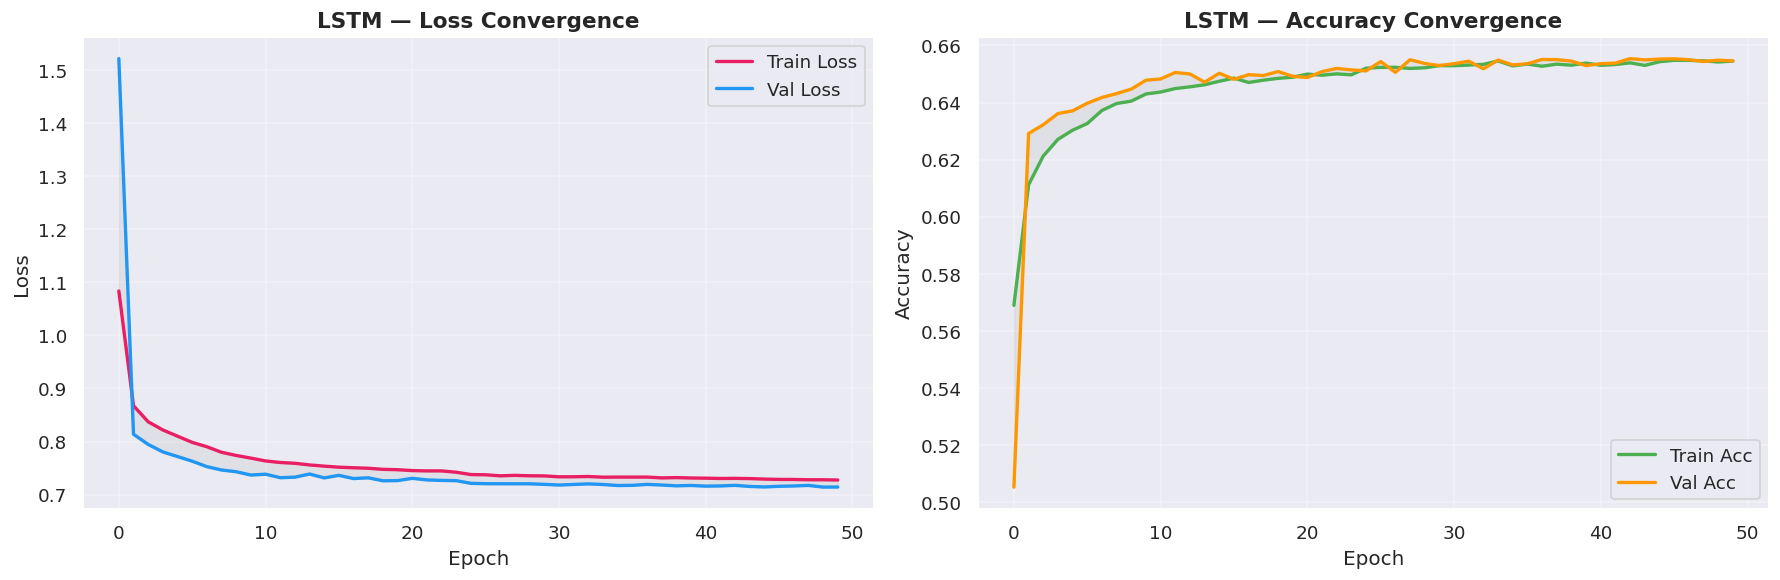

In [31]:
# Figure 6: LSTM Training Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(lstm_hist.history['loss'], label='Train Loss', linewidth=2, color='#E91E63')
axes[0].plot(lstm_hist.history['val_loss'], label='Val Loss', linewidth=2, color='#2196F3')
axes[0].fill_between(range(len(lstm_hist.history['loss'])),
                     lstm_hist.history['loss'], lstm_hist.history['val_loss'], alpha=0.1, color='gray')
axes[0].set_title('LSTM — Loss Convergence', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(lstm_hist.history['accuracy'], label='Train Acc', linewidth=2, color='#4CAF50')
axes[1].plot(lstm_hist.history['val_accuracy'], label='Val Acc', linewidth=2, color='#FF9800')
axes[1].fill_between(range(len(lstm_hist.history['accuracy'])),
                     lstm_hist.history['accuracy'], lstm_hist.history['val_accuracy'], alpha=0.1, color='gray')
axes[1].set_title('LSTM — Accuracy Convergence', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Deep Autoencoder Classifier

In [32]:
print("=" * 60)
print("MODEL 6: DEEP AUTOENCODER CLASSIFIER")
print("=" * 60)

# Autoencoder-based classifier:
# Encoder compresses features → Bottleneck → Classification head
input_dim = X_train.shape[1]

ae_model = Sequential([
    # Encoder
    Dense(256, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Bottleneck
    Dense(64, activation='relu', name='bottleneck'),
    BatchNormalization(),
    
    # Decoder / Classification Head
    Dense(128, activation='relu'),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(n_classes, activation='softmax')
])

ae_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ae_model.summary()

es_ae = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
rlr_ae = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

t0 = time.time()
ae_hist = ae_model.fit(
    X_train.values, y_train_cat,
    epochs=50, batch_size=512,
    validation_split=0.15,
    callbacks=[es_ae, rlr_ae],
    verbose=1
)
ae_time = time.time() - t0
train_times['Autoencoder'] = ae_time

y_pred_ae_prob = ae_model.predict(X_test.values)
y_pred_ae = np.argmax(y_pred_ae_prob, axis=1)
preds['Autoencoder'] = y_pred_ae

results['Autoencoder'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ae),
    'Precision': precision_score(y_test, y_pred_ae, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_ae, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ae, average='weighted', zero_division=0),
}

print(f"\nAutoencoder Results:")
for m, v in results['Autoencoder'].items():
    print(f"  {m}: {v:.4f}")
print(f"Training time: {ae_time:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ae, target_names=le.classes_, zero_division=0))

MODEL 6: DEEP AUTOENCODER CLASSIFIER


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,827 (249.32 KB)

 Trainable params: 62,931 (245.82 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5815 - loss: 1.0272 - val_accuracy: 0.5964 - val_loss: 1.1046 - learning_rate: 0.0010
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6255 - loss: 0.8265 - val_accuracy: 0.6359 - val_loss: 0.7796 - learning_rate: 0.0010
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6351 - loss: 0.7979 - val_accuracy: 0.6422 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6407 - loss: 0.7791 - val_accuracy: 0.6338 - val_loss: 0.7662 - learning_rate: 0.0010
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6442 - loss: 0.7673 - val_accuracy: 0.6473 - val_loss: 0.7436 - learning_rate: 0.0010
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6480 - loss: 0.7579 - val_accuracy: 0.6485 - val_loss: 0.7367 - learning_rate: 0.0010
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6496 - loss: 0.7532 - 

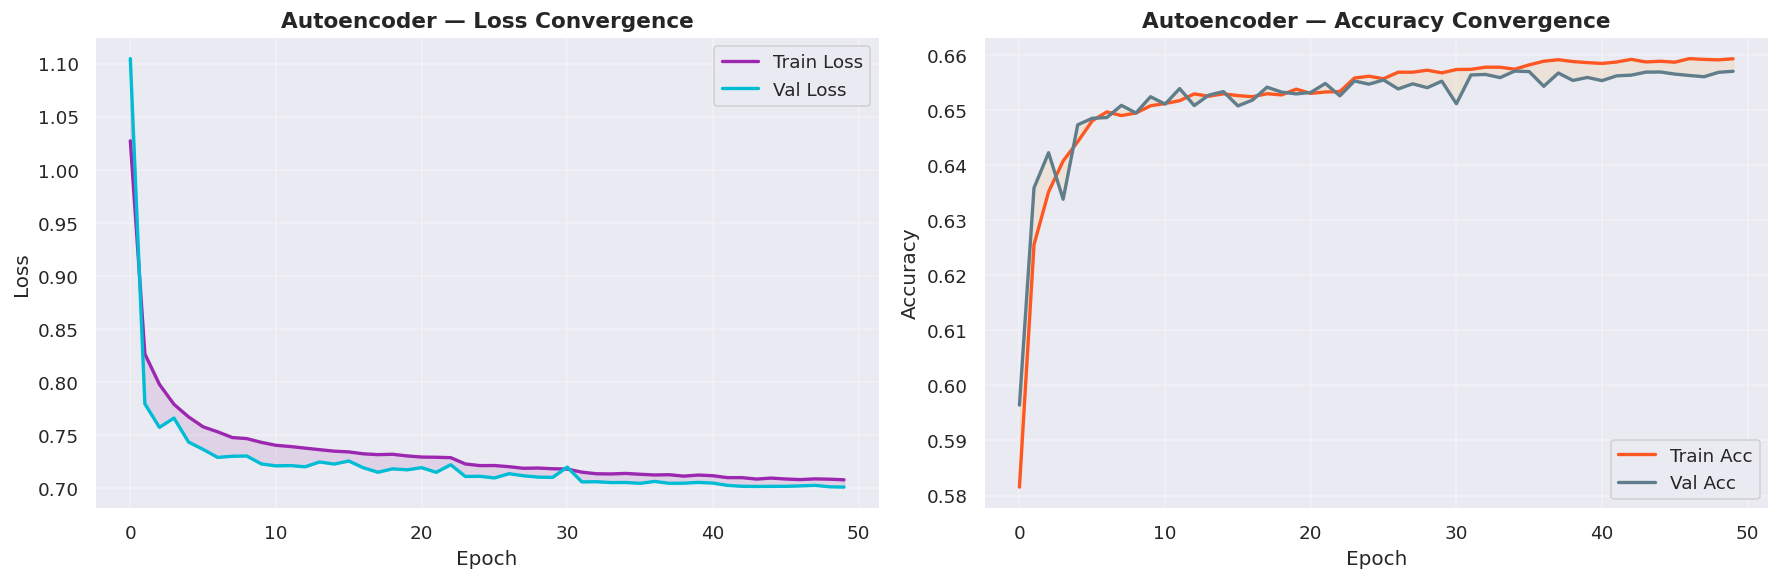

In [33]:
# Figure 7: Autoencoder Training Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(ae_hist.history['loss'], label='Train Loss', linewidth=2, color='#9C27B0')
axes[0].plot(ae_hist.history['val_loss'], label='Val Loss', linewidth=2, color='#00BCD4')
axes[0].fill_between(range(len(ae_hist.history['loss'])),
                     ae_hist.history['loss'], ae_hist.history['val_loss'], alpha=0.1, color='purple')
axes[0].set_title('Autoencoder — Loss Convergence', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ae_hist.history['accuracy'], label='Train Acc', linewidth=2, color='#FF5722')
axes[1].plot(ae_hist.history['val_accuracy'], label='Val Acc', linewidth=2, color='#607D8B')
axes[1].fill_between(range(len(ae_hist.history['accuracy'])),
                     ae_hist.history['accuracy'], ae_hist.history['val_accuracy'], alpha=0.1, color='orange')
axes[1].set_title('Autoencoder — Accuracy Convergence', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Comprehensive Results and Visualisations

In [34]:
# Final Results Table
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

results_df = pd.DataFrame(results).T
results_df['Time (s)'] = pd.Series(train_times)
results_df = results_df.round(4)
print(results_df.to_string())

FINAL MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score  Time (s)
Logistic Regression    0.6098     0.6008  0.6098    0.5644  103.8179
SVM (LinearSVC)        0.5889     0.5747  0.5889    0.5304  502.7958
Naive Bayes            0.5928     0.5951  0.5928    0.5480    1.5639
AdaBoost               0.5610     0.5402  0.5610    0.4815   94.9778
LSTM                   0.6569     0.6532  0.6569    0.5886  179.0343
Autoencoder            0.6610     0.6486  0.6610    0.6097  127.7673


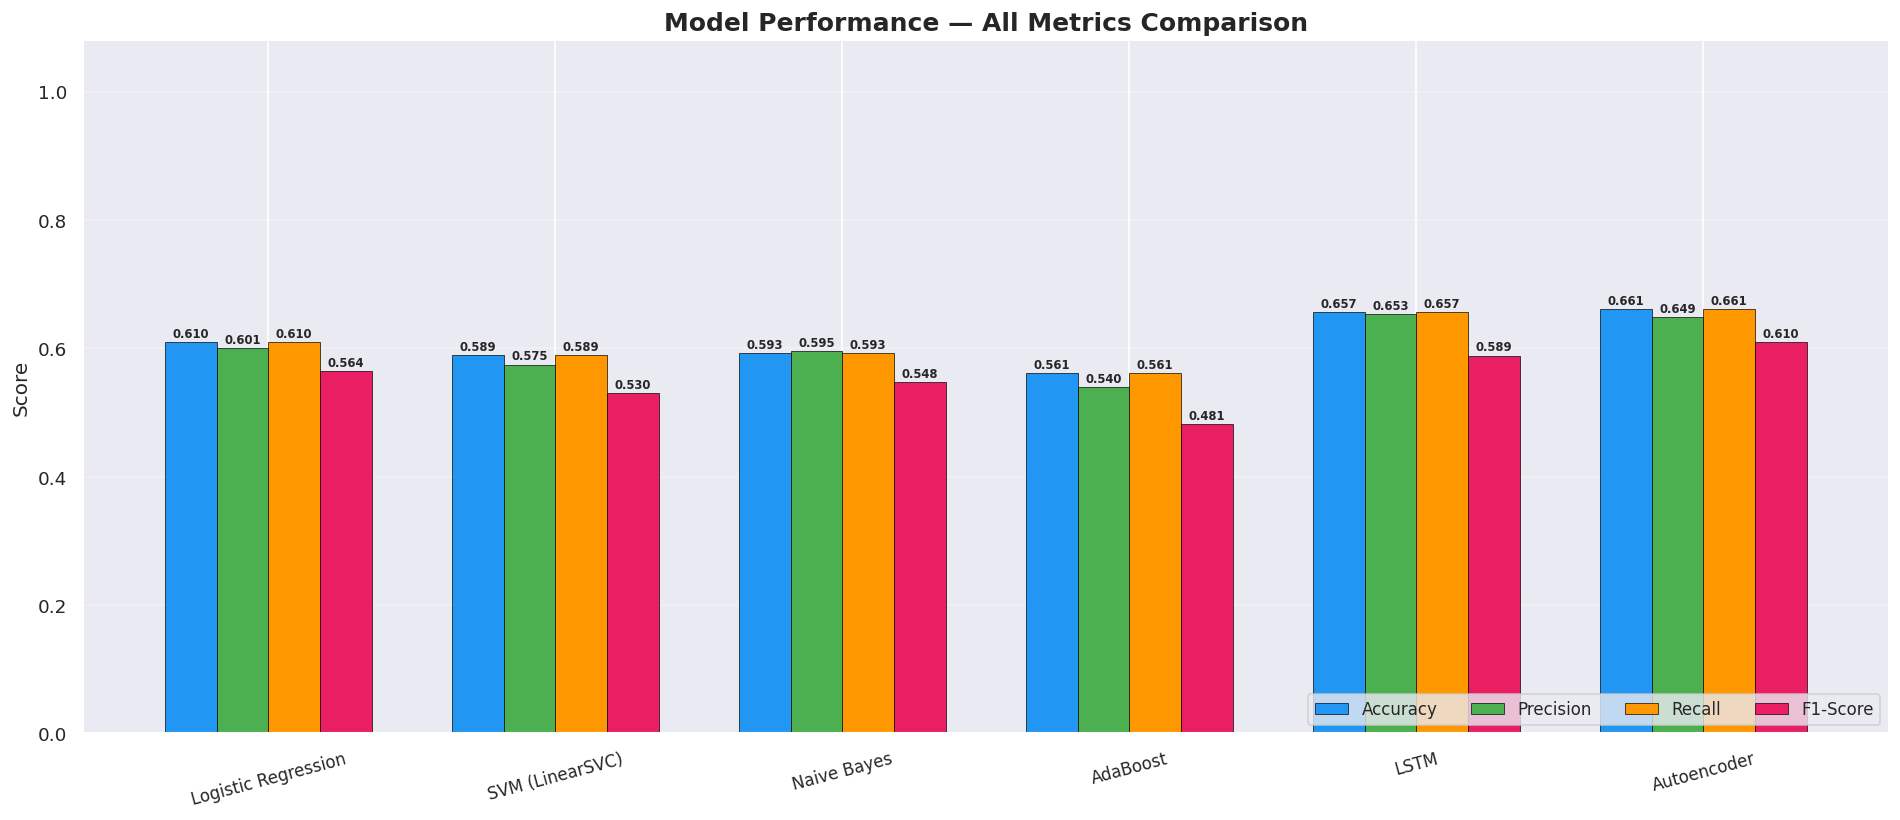

In [35]:
# Figure 8: Grouped Bar Chart — All Metrics Side by Side
fig, ax = plt.subplots(figsize=(16, 7))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.18
colors_group = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=colors_group[i],
                  edgecolor='black', linewidth=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=10, rotation=15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance — All Metrics Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, ncol=4)
ax.set_ylim([0, 1.08])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_grouped_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

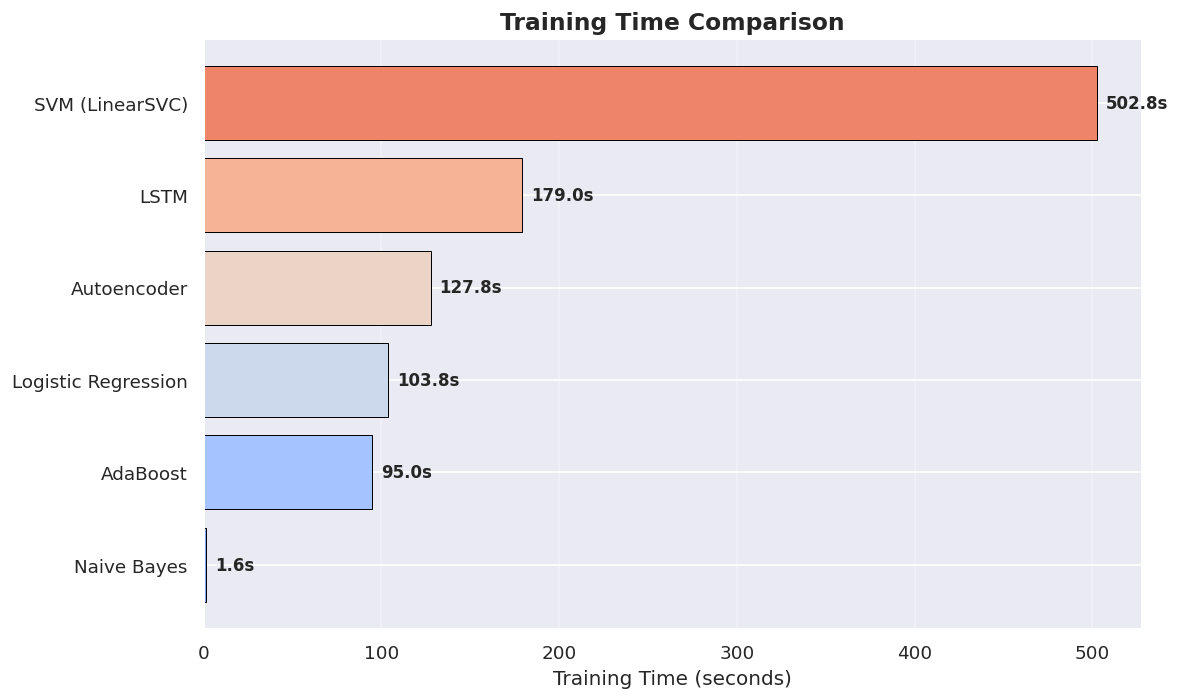

In [36]:
# Figure 9: Training Time (Log Scale)
fig, ax = plt.subplots(figsize=(10, 6))
models_sorted = sorted(train_times.items(), key=lambda x: x[1])
names = [m[0] for m in models_sorted]
times = [m[1] for m in models_sorted]

colors_time = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(names)))
bars = ax.barh(names, times, color=colors_time, edgecolor='black', linewidth=0.6)

for bar, t in zip(bars, times):
    ax.text(bar.get_width() + max(times)*0.01, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_training_time.png', dpi=150, bbox_inches='tight')
plt.show()

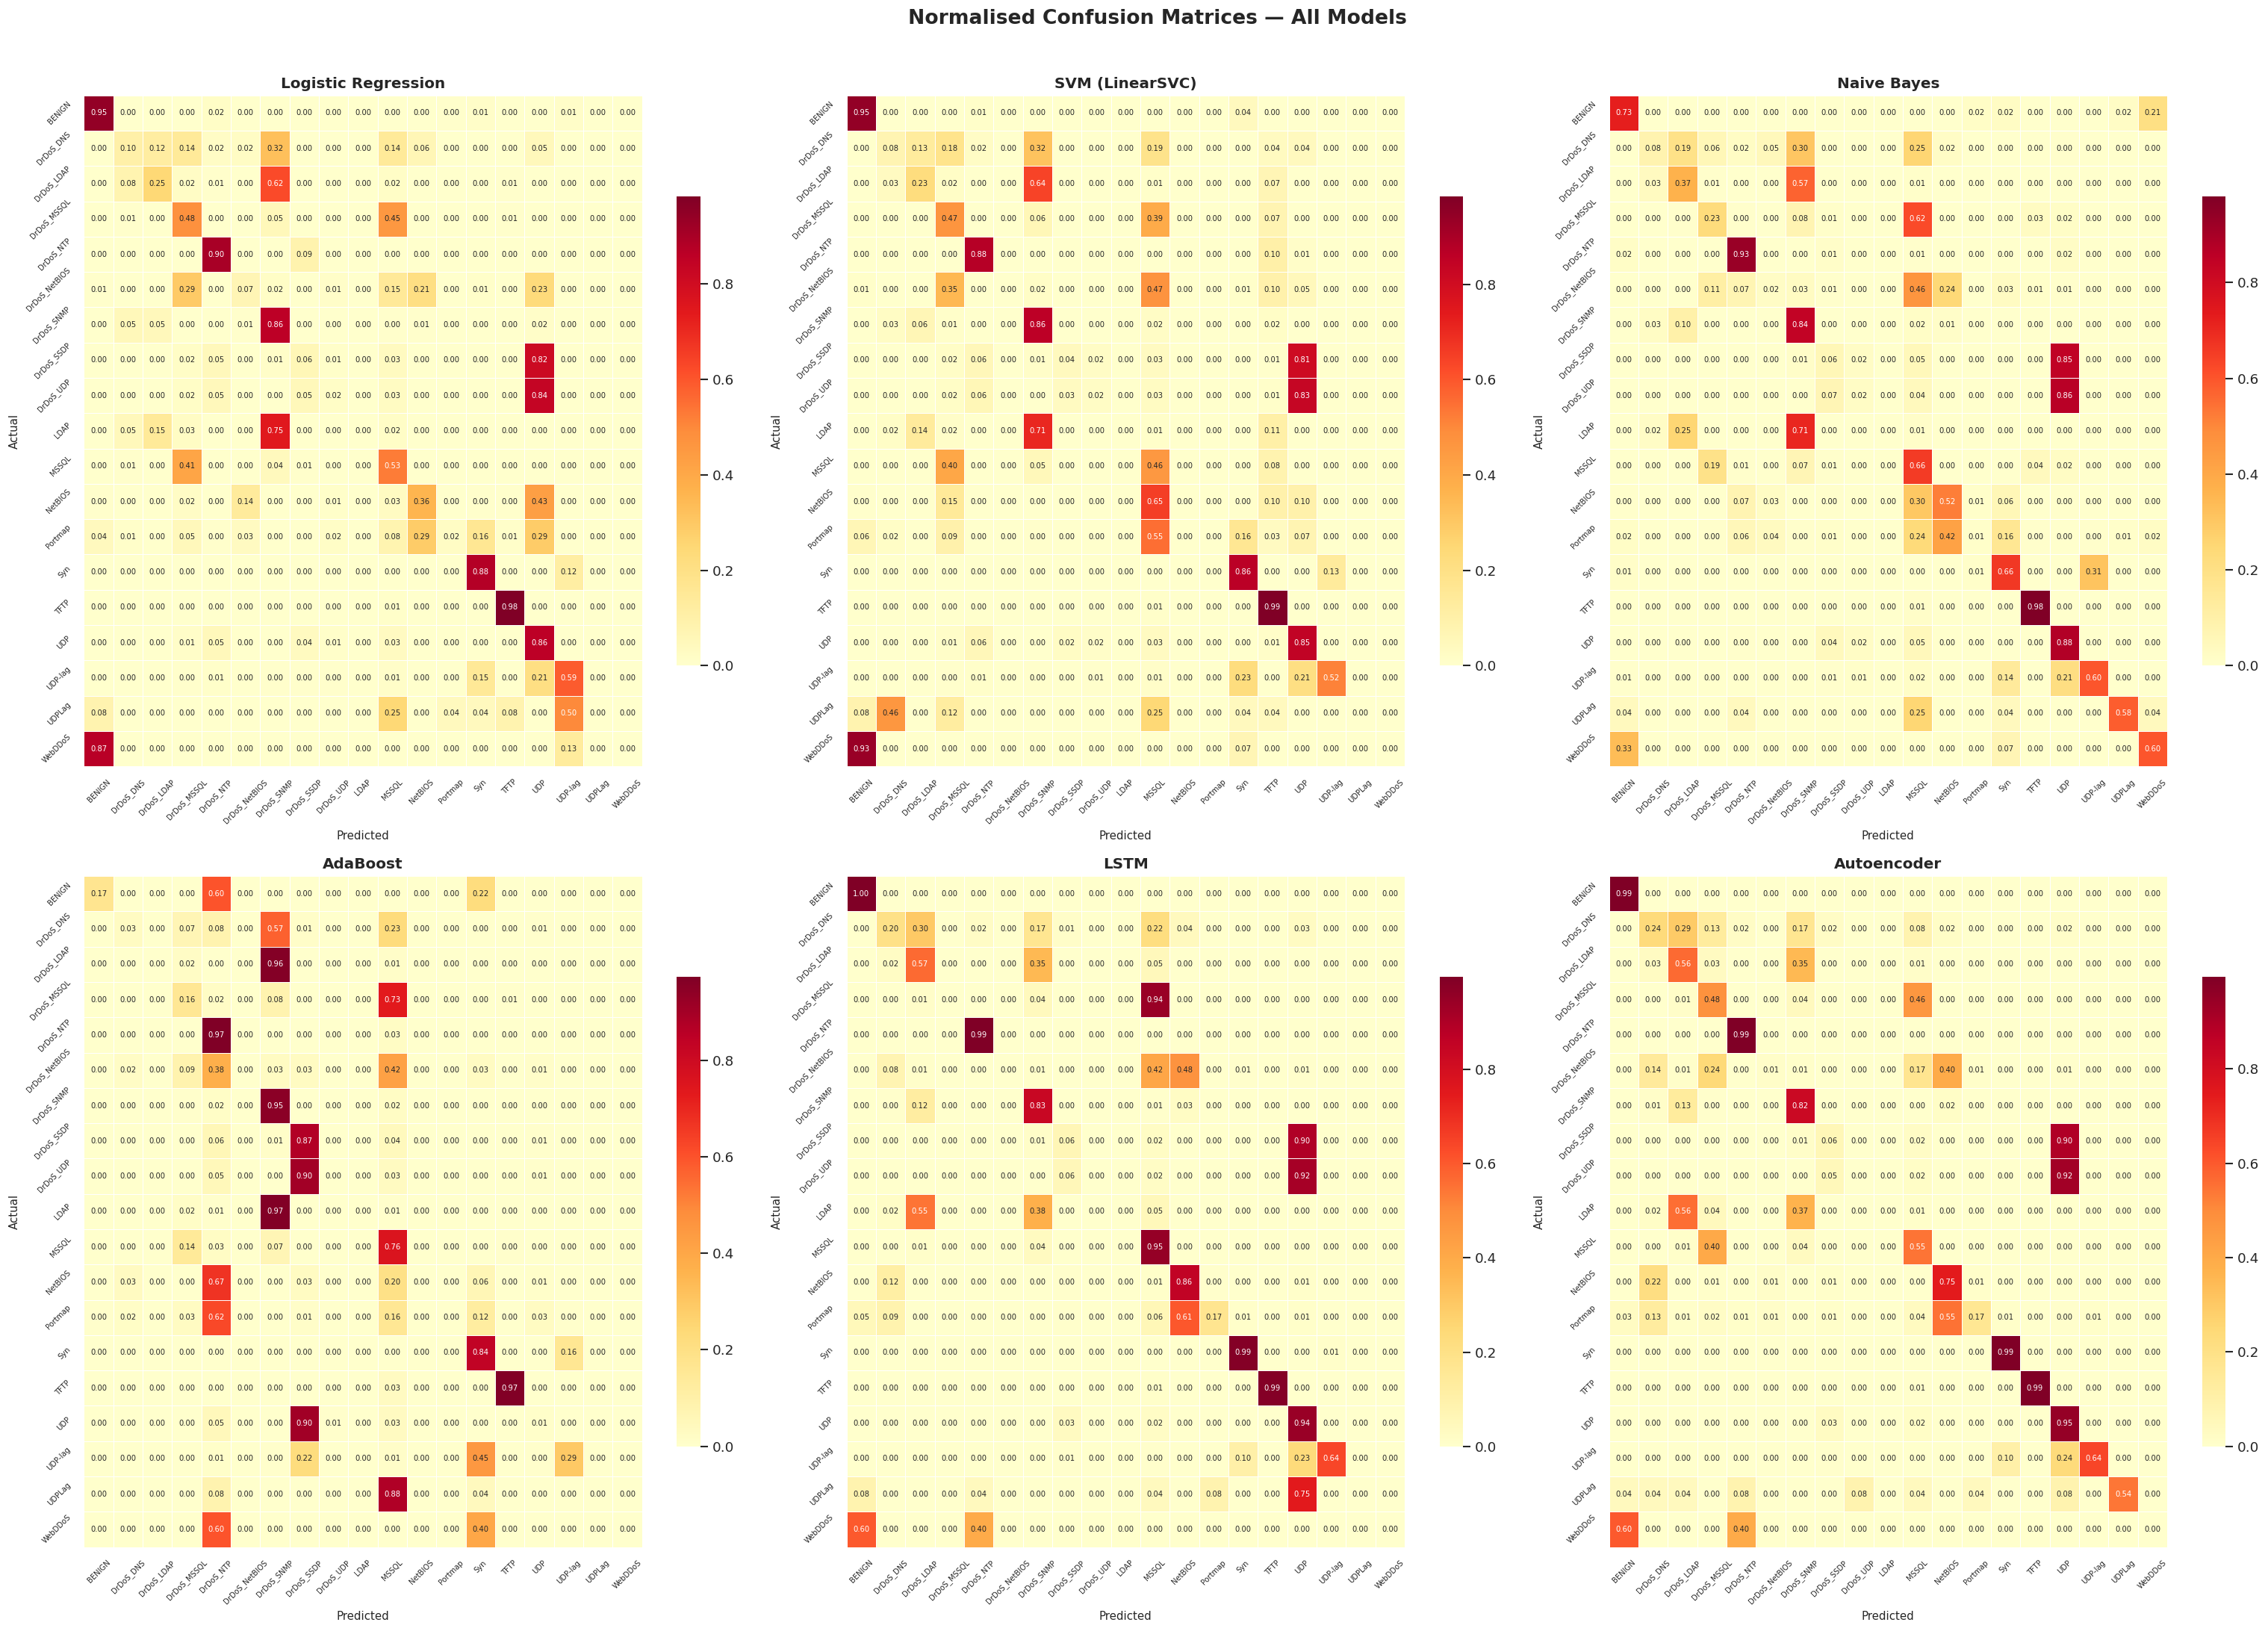

In [37]:
# Figure 10: Confusion Matrices — All 6 Models (3x2 grid)
fig, axes = plt.subplots(2, 3, figsize=(26, 18))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.3, annot_kws={"size": 6},
                cbar_kws={"shrink": 0.7})
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=9)
    axes[idx].set_ylabel('Actual', fontsize=9)
    axes[idx].tick_params(labelsize=6, rotation=45)

plt.suptitle('Normalised Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

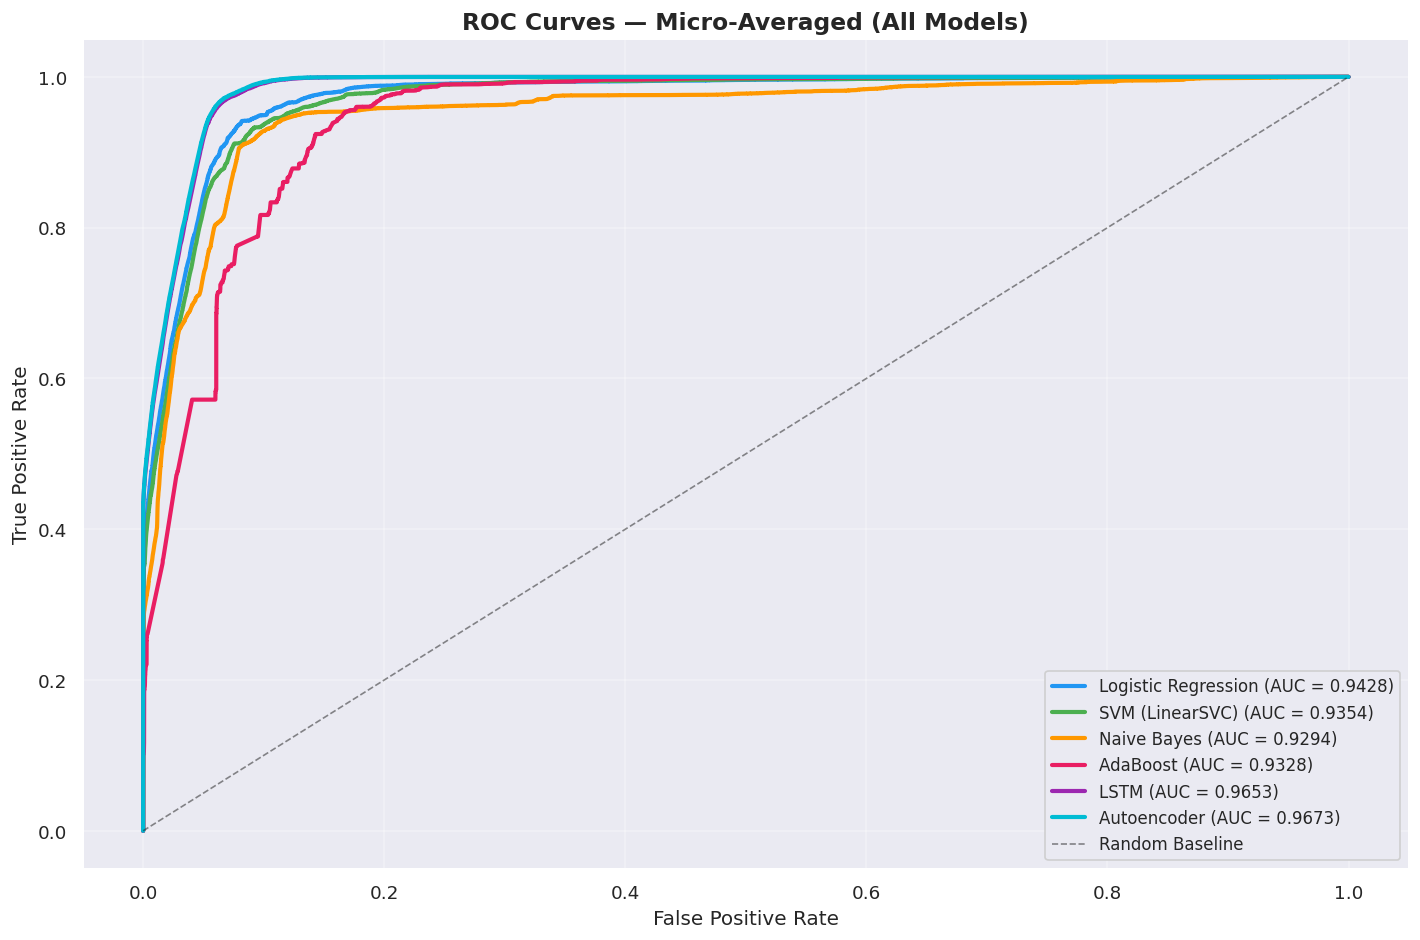

In [38]:
# Figure 11: ROC-AUC Curves
fig, ax = plt.subplots(figsize=(12, 8))

y_test_bin = to_categorical(y_test.values, num_classes=n_classes)
roc_auc_dict = {}

# Get probability outputs
prob_models = {}

# Logistic Regression
try:
    prob_models['Logistic Regression'] = lr_grid.predict_proba(X_test)
except:
    pass

# SVM — calibrate for probabilities
try:
    cal_svm = CalibratedClassifierCV(svm_grid.best_estimator_, cv=3)
    cal_svm.fit(X_train, y_train)
    prob_models['SVM (LinearSVC)'] = cal_svm.predict_proba(X_test)
except:
    pass

# Naive Bayes
try:
    prob_models['Naive Bayes'] = gnb_grid.predict_proba(X_test)
except:
    pass

# AdaBoost
try:
    prob_models['AdaBoost'] = ada_grid.predict_proba(X_test)
except:
    pass

# LSTM
prob_models['LSTM'] = y_pred_lstm_prob

# Autoencoder
prob_models['Autoencoder'] = y_pred_ae_prob

roc_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for (name, probs), color in zip(prob_models.items(), roc_colors):
    try:
        macro_auc = roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro')
        roc_auc_dict[name] = macro_auc
        
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'{name} (AUC = {macro_auc:.4f})')
    except Exception as e:
        print(f"ROC skip for {name}: {e}")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Micro-Averaged (All Models)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Add ROC-AUC to results
for name, auc_val in roc_auc_dict.items():
    results[name]['ROC-AUC'] = auc_val

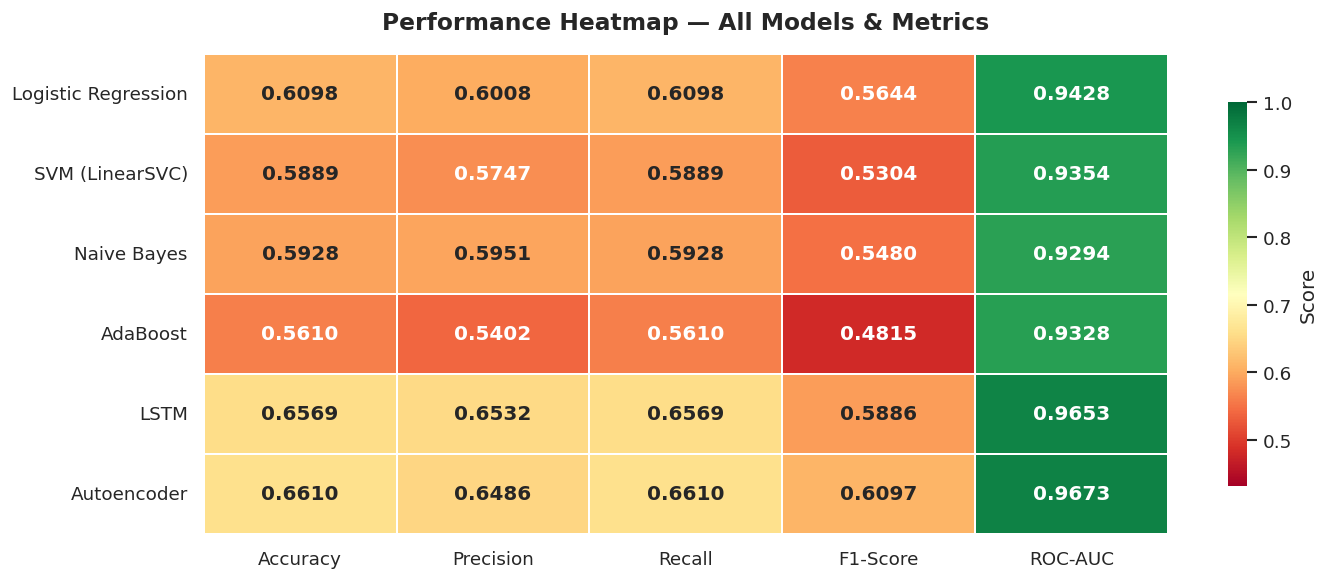

In [40]:
# Figure 12: Heatmap Summary Table
fig, ax = plt.subplots(figsize=(12, 5))

final_df = pd.DataFrame(results).T
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
if 'ROC-AUC' in final_df.columns:
    metric_cols.append('ROC-AUC')

heatmap_data = final_df[metric_cols].astype(float)

sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', linewidths=1,
            ax=ax, annot_kws={"size": 12, "fontweight": "bold"},
            cbar_kws={"label": "Score", "shrink": 0.8},
            vmin=heatmap_data.values.min() - 0.05, vmax=1.0)
ax.set_title('Performance Heatmap — All Models & Metrics', fontsize=14, fontweight='bold', pad=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
plt.tight_layout()
plt.savefig('fig12_heatmap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Final Summary
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

final_results = pd.DataFrame(results).T
final_results['Time (s)'] = pd.Series(train_times)
final_results = final_results.round(4)
print(final_results.to_string())

print("\nBEST MODEL PER METRIC:")
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best = final_results[col].idxmax()
    print(f"  {col}: {best} ({final_results[col].max():.4f})")

if 'ROC-AUC' in final_results.columns:
    best_roc = final_results['ROC-AUC'].idxmax()
    print(f"  ROC-AUC: {best_roc} ({final_results['ROC-AUC'].max():.4f})")

FINAL SUMMARY
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Time (s)
Logistic Regression    0.6098     0.6008  0.6098    0.5644   0.9428  103.8179
SVM (LinearSVC)        0.5889     0.5747  0.5889    0.5304   0.9354  502.7958
Naive Bayes            0.5928     0.5951  0.5928    0.5480   0.9294    1.5639
AdaBoost               0.5610     0.5402  0.5610    0.4815   0.9328   94.9778
LSTM                   0.6569     0.6532  0.6569    0.5886   0.9653  179.0343
Autoencoder            0.6610     0.6486  0.6610    0.6097   0.9673  127.7673

BEST MODEL PER METRIC:
  Accuracy: Autoencoder (0.6610)
  Precision: LSTM (0.6532)
  Recall: Autoencoder (0.6610)
  F1-Score: Autoencoder (0.6097)
  ROC-AUC: Autoencoder (0.9673)
